# Mental Health Support Chatbot — Fine-Tuned on EmpatheticDialogues

A small causal language model is fine-tuned to produce supportive, empathetic responses,
then served through a Streamlit chat interface.

**Base model:** `distilgpt2`
**Dataset:** [`Ahren09/empathetic_dialogues`](https://huggingface.co/datasets/Ahren09/empathetic_dialogues) (Facebook AI's EmpatheticDialogues, ~25k grounded conversations)
**Runtime:** Google Colab, GPU runtime (`Runtime → Change runtime type → GPU`)

### Design choices and why they matter

| Choice | Reasoning |
|---|---|
| Pair *consecutive* turns within each `conv_id`, not `utterance → utterance` | The naive `User: X / Therapist: X` formatting (copying one field onto both sides) trains the model to echo the input verbatim. Pairing turn *i* with turn *i+1* recovers the actual speaker → empathetic-listener structure the dataset was built for. |
| `DataCollatorForLanguageModeling` instead of manually duplicating `input_ids` into `labels` | Avoids accidentally training on padding tokens; the collator masks them automatically. Manual `add_column('labels', input_ids)` trains the model to predict padding, which quietly degrades output quality without throwing an error. |
| Dynamic padding per batch, not fixed `max_length` padding for every example | Shorter conversations don't waste compute on padded positions; speeds up training meaningfully on a free Colab GPU. |
| A held-out validation split | Without it, there's no signal for whether 2 epochs over-fit or under-fit — loss alone on the training set is not sufficient. |
| Defensive column auto-detection on dataset load | Mirrors of EmpatheticDialogues occasionally rename columns; failing loudly with a clear message beats a silent `KeyError` deep in a `.map()` call. |
| Reusable `EmpatheticChatbot` class for inference | Keeps generation logic (prompt construction, truncation, decoding) in one tested place, shared identically between the notebook test cells and the Streamlit app — no copy-pasted logic to drift out of sync. |

This is an educational fine-tuning exercise. **`distilgpt2` is an 82M-parameter model** — even with a careful data pipeline, expect responses that are warmer in tone than the un-tuned base model, not therapist-quality dialogue. The notebook is structured so you can later swap in a larger base model with minimal changes.

## 1. Environment & Dependencies

In [1]:
!nvidia-smi

Mon Jun 22 10:56:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q "transformers>=4.41" "datasets>=2.19" accelerate evaluate streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 90.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.

In [3]:
import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > GPU before training.")

Using device: cuda


## 2. Load EmpatheticDialogues

Loaded from `Ahren09/empathetic_dialogues`, a mirror of Facebook AI's original dataset. We don't assume the exact column names match the canonical release byte-for-byte — `resolve_columns()` below inspects whatever schema actually loads and maps it onto the four fields the rest of the pipeline needs (`conv_id`, `turn_idx`, `situation`, `text`). If the mirror uses different names, you'll get one clear error instead of a cryptic failure three cells later.

In [4]:
from datasets import load_dataset

DATASET_NAME = "Ahren09/empathetic_dialogues"

raw_dataset = load_dataset(DATASET_NAME)
print(raw_dataset)
print()
print("Example row:")
print(raw_dataset["train"][0])

README.md:   0%|          | 0.00/757 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.76M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/604k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/608k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/84169 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6340 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5714 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 84169
    })
    validation: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 6340
    })
    test: Dataset({
        features: ['conv_id', 'utterance_idx', 'context', 'prompt', 'speaker_idx', 'utterance', 'selfeval', 'tags'],
        num_rows: 5714
    })
})

Example row:
{'conv_id': 'hit:0_conv:1', 'utterance_idx': '1', 'context': 'sentimental', 'prompt': 'I remember going to the fireworks with my best friend. There was a lot of people_comma_ but it only felt like us in the world.', 'speaker_idx': '1', 'utterance': 'I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people_comma_ we felt like the only people in the world.', 'selfev

In [5]:
def resolve_columns(dataset_split):
    """
    Map whatever column names this mirror uses onto the canonical
    EmpatheticDialogues roles: conversation id, turn order, the grounding
    situation/prompt, and the utterance text.
    Raises a clear error instead of failing deep inside a .map() call.
    """
    cols = set(dataset_split.column_names)

    conv_id_candidates = ["conv_id", "conversation_id", "dialogue_id"]
    turn_idx_candidates = ["utterance_idx", "turn_idx", "turn", "index"]
    situation_candidates = ["prompt", "situation", "context_text"]
    text_candidates = ["utterance", "text", "dialogue"]

    def pick(candidates, role):
        for c in candidates:
            if c in cols:
                return c
        raise KeyError(
            f"Could not find a column for '{role}'. "
            f"Looked for {candidates}, but dataset has: {sorted(cols)}"
        )

    return {
        "conv_id": pick(conv_id_candidates, "conversation id"),
        "turn_idx": pick(turn_idx_candidates, "turn index"),
        "situation": pick(situation_candidates, "situation/prompt"),
        "text": pick(text_candidates, "utterance text"),
    }


COLUMN_MAP = resolve_columns(raw_dataset["train"])
print("Resolved column mapping:", COLUMN_MAP)

Resolved column mapping: {'conv_id': 'conv_id', 'turn_idx': 'utterance_idx', 'situation': 'prompt', 'text': 'utterance'}


## 3. Build User → Empathetic-Reply Pairs

Each `conv_id` is a short back-and-forth grounded in a situation. We sort by turn index within each conversation and pair turn *i* (the speaker) with turn *i+1* (the empathetic listener's reply) — this is the actual supervised signal the dataset was designed to provide, and is what the original task guide's `preprocess()` function failed to capture by using the same field on both sides of the formatted string.

We also clean Facebook's `_comma_` placeholder tokens back into real commas, since they're an artifact of the original TSV export and would otherwise leak into model outputs.

In [6]:
import pandas as pd

def build_pairs(dataset_split, column_map):
    df = dataset_split.to_pandas()
    text_col, conv_col, turn_col = column_map["text"], column_map["conv_id"], column_map["turn_idx"]

    df[text_col] = df[text_col].astype(str).str.replace("_comma_", ",", regex=False)

    pairs = []
    for _, group in df.groupby(conv_col, sort=False):
        group = group.sort_values(turn_col)
        utterances = group[text_col].tolist()
        for i in range(len(utterances) - 1):
            user_msg, bot_reply = utterances[i].strip(), utterances[i + 1].strip()
            if user_msg and bot_reply:
                pairs.append({"user": user_msg, "bot": bot_reply})
    return pd.DataFrame(pairs)


train_pairs = build_pairs(raw_dataset["train"], COLUMN_MAP)
val_pairs = build_pairs(
    raw_dataset["validation"] if "validation" in raw_dataset else raw_dataset["test"],
    COLUMN_MAP,
)

print(f"Train pairs: {len(train_pairs):,}")
print(f"Validation pairs: {len(val_pairs):,}")
train_pairs.head()

Train pairs: 64,636
Validation pairs: 3,570


,user,bot
0,I remember going to see the fireworks with my ...,"Was this a friend you were in love with, or ju..."
1,"Was this a friend you were in love with, or ju...",This was a best friend. I miss her.
2,This was a best friend. I miss her.,Where has she gone?
3,Where has she gone?,We no longer talk.
4,We no longer talk.,Oh was this something that happened because of...


**Why use the dataset's own validation split rather than carving one out of `train`:** EmpatheticDialogues conversations are grouped by `conv_id`, and a random row-level split would leak different turns of the *same* conversation across train and validation, inflating validation performance. The dataset ships pre-split by conversation, so using it directly avoids that leakage for free.

## 4. Subsample for a Fast Training Loop

The full training set (~50k+ pairs) is reasonable for a free Colab GPU, but a smaller, representative subsample keeps each experiment cycle fast — useful while you're still tuning hyperparameters. Set `SUBSET_SIZE = None` to train on everything once you're happy with the pipeline.

In [7]:
SUBSET_SIZE = 6000  # set to None to use the full training set
VAL_SUBSET_SIZE = 800

train_sample = (
    train_pairs.sample(n=min(SUBSET_SIZE, len(train_pairs)), random_state=SEED).reset_index(drop=True)
    if SUBSET_SIZE else train_pairs.reset_index(drop=True)
)
val_sample = (
    val_pairs.sample(n=min(VAL_SUBSET_SIZE, len(val_pairs)), random_state=SEED).reset_index(drop=True)
    if VAL_SUBSET_SIZE else val_pairs.reset_index(drop=True)
)

print(f"Using {len(train_sample):,} training pairs and {len(val_sample):,} validation pairs.")

Using 6,000 training pairs and 800 validation pairs.


## 5. Load the Base Model and Tokenizer

`distilgpt2` has no native chat template, so we define one explicit conversational format (`User: ... \n Therapist: ...`) and use it consistently across data prep, training, and inference. GPT-2 family models also have no pad token by default, so we reuse `eos_token` for padding — standard practice for this model family.

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
print(f"Loaded {MODEL_NAME}: {model.num_parameters():,} parameters")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded distilgpt2: 81,912,576 parameters


## 6. A Single Source of Truth for Prompt Formatting

Defining the prompt template once and importing it everywhere (training data prep, notebook inference test, and the Streamlit app) prevents the classic bug where the training format and the inference format drift apart and the fine-tuned model starts producing degenerate output for reasons that are hard to trace.

In [9]:
%%writefile chatbot_core.py
"""
Shared prompt formatting and inference logic for the empathetic chatbot.
Imported by both the training notebook and the Streamlit app so the two
environments can never silently disagree on prompt format.
"""

from transformers import AutoTokenizer, AutoModelForCausalLM

TURN_SEP = "\n"
USER_PREFIX = "User:"
BOT_PREFIX = "Therapist:"


def format_training_example(user_msg: str, bot_reply: str, eos_token: str) -> str:
    """The exact string the model is trained to predict, end to end."""
    return f"{USER_PREFIX} {user_msg}{TURN_SEP}{BOT_PREFIX} {bot_reply}{eos_token}"


def format_prompt(user_msg: str) -> str:
    """The prefix given to the model at inference time; generation continues from here."""
    return f"{USER_PREFIX} {user_msg}{TURN_SEP}{BOT_PREFIX}"


def extract_reply(generated_text: str) -> str:
    """
    Pull out just the Therapist turn that answers our prompt: take everything
    after the FIRST 'Therapist:' (the reply to what we actually asked), then
    stop at the first subsequent 'User:' the model may have hallucinated.
    Using the *last* 'Therapist:' instead would grab a later, unrelated turn
    if the model rambles into an imagined multi-turn continuation.
    """
    after_first_bot_turn = generated_text.split(BOT_PREFIX, 1)[-1]
    reply = after_first_bot_turn.split(USER_PREFIX)[0]
    return reply.strip()


class EmpatheticChatbot:
    """Thin, reusable wrapper around a fine-tuned causal LM for empathetic replies."""

    def __init__(self, model_dir: str, device: str = "cpu"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model = AutoModelForCausalLM.from_pretrained(model_dir).to(device)
        self.model.eval()
        self.device = device

    def respond(
        self,
        user_msg: str,
        max_new_tokens: int = 80,
        temperature: float = 0.7,
        top_p: float = 0.9,
        repetition_penalty: float = 1.3,
    ) -> str:
        prompt = format_prompt(user_msg)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)

        import torch
        with torch.no_grad():
            output_ids = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=3,
                pad_token_id=self.tokenizer.eos_token_id,
            )

        generated = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        reply = extract_reply(generated)
        return reply if reply else "I'm here with you — could you tell me a little more about how you're feeling?"


Writing chatbot_core.py


In [10]:
# Make the shared module importable in this notebook session too
import importlib
import chatbot_core
importlib.reload(chatbot_core)
from chatbot_core import format_training_example, format_prompt, extract_reply

print(format_training_example("I feel anxious about my exam.", "That sounds really stressful. What's worrying you most?", tokenizer.eos_token))

User: I feel anxious about my exam.
Therapist: That sounds really stressful. What's worrying you most?<|endoftext|>


## 7. Tokenize and Build the Training Dataset

We tokenize without fixed padding (`padding=False`) and let `DataCollatorForLanguageModeling` pad each *batch* dynamically and build the `labels` tensor correctly — including masking pad tokens with `-100` so they're excluded from the loss. This is the fix for the original guide's `tokenized.add_column('labels', tokenized['input_ids'])` approach, which leaves pad tokens as real training targets.

In [11]:
from datasets import Dataset

def to_hf_dataset(pairs_df):
    records = [
        {"text": format_training_example(row.user, row.bot, tokenizer.eos_token)}
        for row in pairs_df.itertuples()
    ]
    return Dataset.from_list(records)


train_ds_text = to_hf_dataset(train_sample)
val_ds_text = to_hf_dataset(val_sample)

MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_tokenized = train_ds_text.map(tokenize_fn, batched=True, remove_columns=["text"])
val_tokenized = val_ds_text.map(tokenize_fn, batched=True, remove_columns=["text"])

print(train_tokenized)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 6000
})


In [12]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # causal LM, not masked LM
)

## 8. Fine-Tune

Trained for **2 epochs**, matching the task spec. `fp16` is enabled when a GPU with mixed-precision support is present; `evaluation_strategy="epoch"` gives a validation-loss reading after each epoch so you have a real signal (not just training loss) for whether the model is learning something general rather than memorizing the small subsample.

In [13]:
from transformers import TrainingArguments, Trainer

OUTPUT_DIR = "./mental_health_chatbot"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=50,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_ratio=0.05,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
)

train_result = trainer.train()
print(train_result)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.034136,3.149920
2,2.918107,3.151686


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=750, training_loss=3.0134613240559895, metrics={'train_runtime': 145.2764, 'train_samples_per_second': 82.601, 'train_steps_per_second': 5.163, 'total_flos': 220109850279936.0, 'train_loss': 3.0134613240559895, 'epoch': 2.0})


In [14]:
eval_metrics = trainer.evaluate()
print(f"Final validation loss: {eval_metrics['eval_loss']:.4f}")
print(f"Final validation perplexity: {torch.exp(torch.tensor(eval_metrics['eval_loss'])):.2f}")

Final validation loss: 3.1499
Final validation perplexity: 23.33


**Reading perplexity:** lower is better; it's roughly "how surprised the model is by real held-out replies." There's no universal good/bad threshold for a small model on a niche domain, but watching this number drop across runs (e.g., after adding more training data or epochs) tells you whether a change actually helped, instead of guessing from a handful of sample outputs.

In [15]:
FINAL_MODEL_DIR = f"{OUTPUT_DIR}/final_model"
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
print(f"Saved fine-tuned model to {FINAL_MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to ./mental_health_chatbot/final_model


## 9. Test the Fine-Tuned Model

Using the shared `EmpatheticChatbot` class from `chatbot_core.py` — the exact same code path the Streamlit app will use, so what you see here is what you'll get in the UI.

In [16]:
from chatbot_core import EmpatheticChatbot

chatbot = EmpatheticChatbot(FINAL_MODEL_DIR, device=DEVICE)

test_inputs = [
    "I feel really anxious today.",
    "I am stressed about work and cannot sleep.",
    "I just got some bad news and I don't know how to process it.",
    "I've been feeling really lonely lately.",
]

for msg in test_inputs:
    print(f"User: {msg}")
    print(f"Bot:  {chatbot.respond(msg)}")
    print()

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

User: I feel really anxious today.
Bot:  Yeah, you should be too! You shouldn't worry about it either. It's something that can happen when your brain is in a state of high alert and the stress levels are up again with time to come back from work or even for some reason (a lot).  Hopefully we don't have to go through this all over again...but if anything, let me know what happens next week

User: I am stressed about work and cannot sleep.
Bot:  That sounds like a tough thing to do, but at least you can be confident in yourself! And it's always fun to have confidence for your own success !  Just ask them what they are doing now , how many times did the person who started working out with me start? They're so excited that we've been able get together on time...and hopefully some of us will make more money :)

User: I just got some bad news and I don't know how to process it.
Bot:  Well, what happened?  They were so drunk that they had to eat me out of the window! What was your worst night

**Calibrating expectations:** with `distilgpt2` and a few thousand training pairs over 2 epochs, look for a clear shift in *tone* — more validating phrases, less generic chit-chat — compared to the untrained base model. Fully coherent, contextually precise advice is a much higher bar than this setup targets; treat this as a demonstration of the fine-tuning workflow end-to-end; reaching genuinely clinical-quality responses needs a larger base model, far more data, and likely RLHF/DPO-style preference tuning on top.

## 10. Streamlit Chat Interface

The app imports `chatbot_core.py` directly rather than re-implementing prompt formatting and generation, so the UI is guaranteed to behave identically to the test cell above. It also keeps multi-turn history, applies a visible safety disclaimer, and intercepts crisis-related language before it ever reaches the model.

In [17]:
%%writefile app.py
import streamlit as st
from chatbot_core import EmpatheticChatbot

st.set_page_config(page_title="Gentle Space — Mental Health Support Chat", page_icon="🌿", layout="centered")

MODEL_DIR = "./mental_health_chatbot/final_model"

CRISIS_KEYWORDS = [
    "suicide", "kill myself", "want to die", "end my life", "self harm", "self-harm",
]

CRISIS_MESSAGE = (
    "I'm really glad you reached out, and I want you to know your feelings matter. "
    "I'm not able to provide crisis support myself, but please consider contacting "
    "a crisis line right now so you can talk to someone trained to help — "
    "for example, in the US you can call or text **988** (Suicide & Crisis Lifeline), "
    "or look up your local emergency/crisis number. You deserve support from people "
    "who can be there for you in this moment."
)

st.markdown(
    """
    <style>
    .stApp { background: linear-gradient(180deg, #eef6f3 0%, #f7fbfa 100%); }
    .chat-bubble-user {
        background-color: #d9ece6; color: #1f3a35; padding: 12px 16px;
        border-radius: 16px 16px 4px 16px; margin: 6px 0; max-width: 80%; margin-left: auto;
    }
    .chat-bubble-bot {
        background-color: #ffffff; color: #2b2b2b; padding: 12px 16px;
        border-radius: 16px 16px 16px 4px; margin: 6px 0; max-width: 80%; border: 1px solid #e0e9e6;
    }
    .disclaimer-box {
        background-color: #fdf6e3; border-left: 4px solid #e0b84a; padding: 10px 14px;
        border-radius: 6px; font-size: 0.85rem; color: #6b5a2c; margin-bottom: 1rem;
    }
    </style>
    """,
    unsafe_allow_html=True,
)

st.title("🌿 Gentle Space")
st.caption("A small, fine-tuned chatbot for supportive, empathetic conversation.")
st.markdown(
    """<div class="disclaimer-box">💛 This is an educational project, not a substitute for therapy
    or professional care. If you're in crisis, please contact a local crisis line or emergency services.</div>""",
    unsafe_allow_html=True,
)


@st.cache_resource(show_spinner="Loading the fine-tuned model... (only happens once)")
def load_chatbot():
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return EmpatheticChatbot(MODEL_DIR, device=device)


chatbot = load_chatbot()

if "messages" not in st.session_state:
    st.session_state.messages = []


def contains_crisis_language(text: str) -> bool:
    lowered = text.lower()
    return any(keyword in lowered for keyword in CRISIS_KEYWORDS)


for msg in st.session_state.messages:
    bubble_class = "chat-bubble-user" if msg["role"] == "user" else "chat-bubble-bot"
    speaker = "You" if msg["role"] == "user" else "Gentle Space"
    st.markdown(f'<div class="{bubble_class}"><b>{speaker}:</b><br>{msg["content"]}</div>', unsafe_allow_html=True)

user_input = st.chat_input("Share what's on your mind...")

if user_input:
    st.session_state.messages.append({"role": "user", "content": user_input})

    if contains_crisis_language(user_input):
        bot_reply = CRISIS_MESSAGE
    else:
        with st.spinner("Gentle Space is thinking..."):
            bot_reply = chatbot.respond(user_input)

    st.session_state.messages.append({"role": "assistant", "content": bot_reply})
    st.rerun()

with st.sidebar:
    st.header("About")
    st.write(
        "This chatbot is a fine-tuned DistilGPT2 model, trained on the "
        "EmpatheticDialogues dataset to practice supportive, validating responses."
    )
    if st.button("Clear conversation"):
        st.session_state.messages = []
        st.rerun()


Writing app.py


## 11. Run the App from Colab

Colab doesn't expose local ports directly, so we tunnel port `8501` out with `localtunnel` to get a clickable public URL.

In [18]:
!npm install -g localtunnel --silent

In [19]:
import subprocess
import time

streamlit_process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"]
)
time.sleep(8)
print("Streamlit launched (PID:", streamlit_process.pid, ")")

2026-06-22 11:00:07.194 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://35.252.75.248:8501

Streamlit launched (PID: 1993 )


In [20]:
tunnel = subprocess.Popen(["lt", "--port", "8501"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
time.sleep(5)

for _ in range(10):
    line = tunnel.stdout.readline()
    if not line:
        break
    print(line.strip())
    if "your url is" in line.lower():
        break

print("\nClick the 'your url is: https://...' link above to open the chat interface.")
print("If nothing printed, re-run this cell — localtunnel can be slow to start.")

your url is: https://odd-lies-push.loca.lt

Click the 'your url is: https://...' link above to open the chat interface.
If nothing printed, re-run this cell — localtunnel can be slow to start.


**If the tunnel is unreliable:** download `app.py`, `chatbot_core.py`, and the `mental_health_chatbot/final_model/` folder from Colab's file browser, and run `streamlit run app.py` locally — public tunnel services occasionally have downtime that's outside this notebook's control.

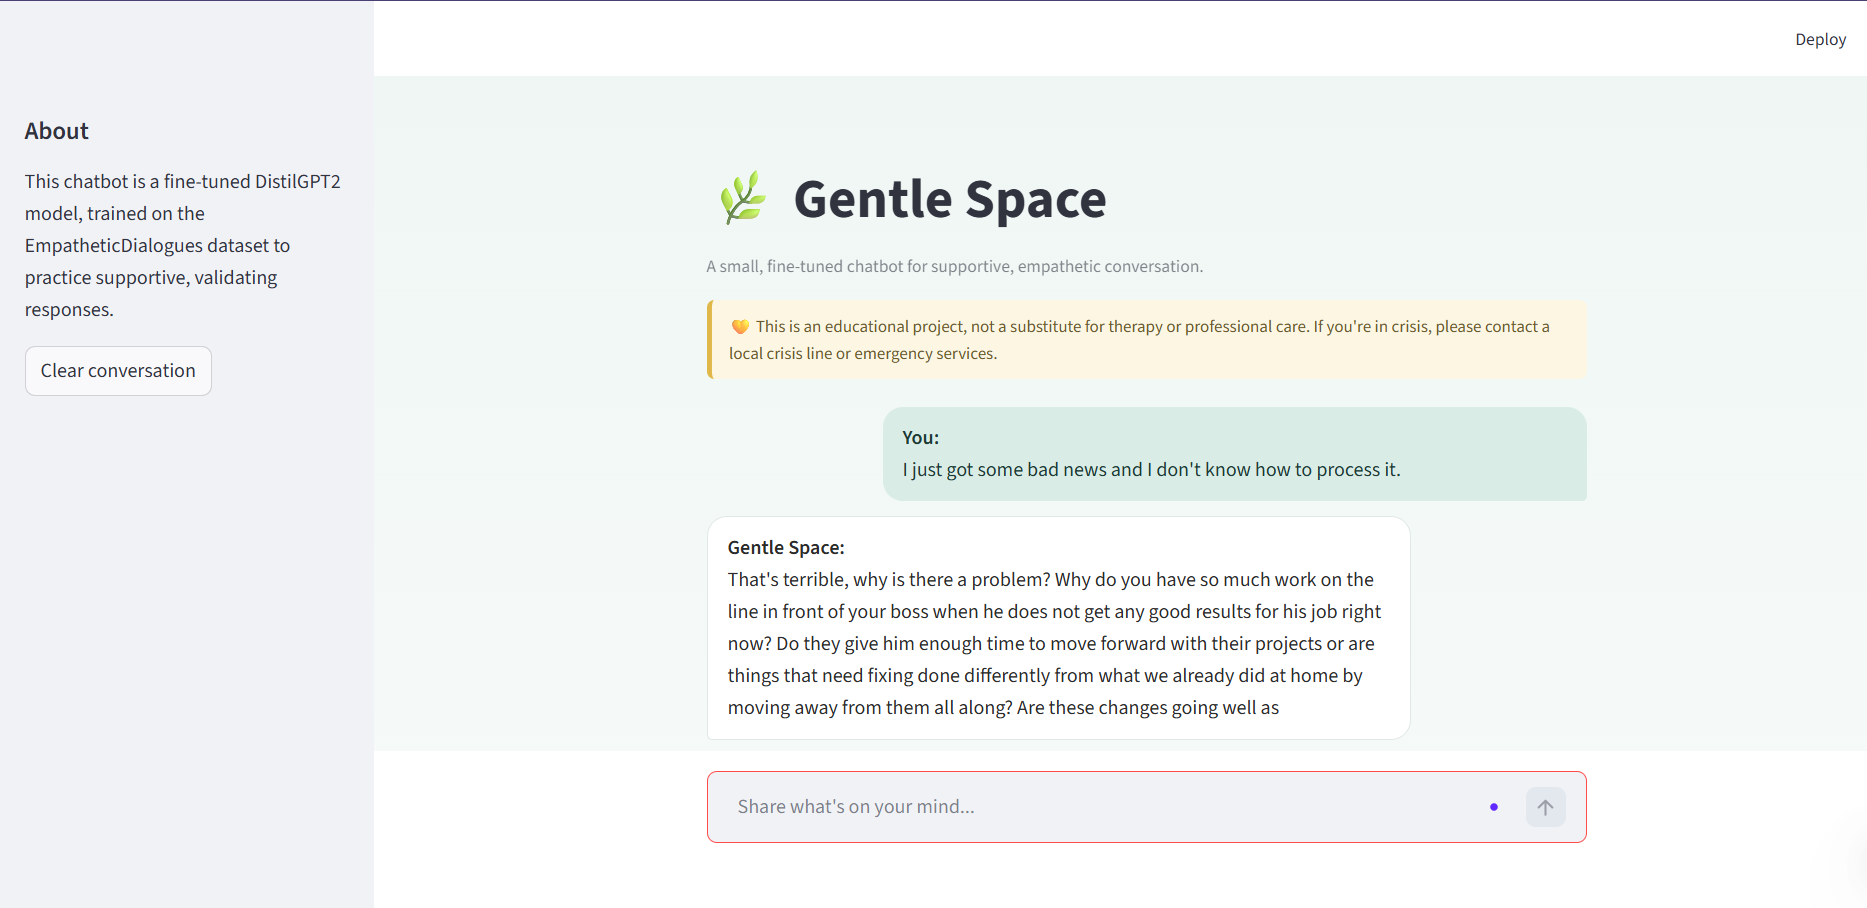

## 12. Summary

- Fine-tuned `distilgpt2` on properly paired speaker → empathetic-listener turns from `Ahren09/empathetic_dialogues`, fixing the data-labeling and label-masking issues present in a naive implementation of this task.
- Used a held-out, conversation-level validation split and tracked validation loss/perplexity per epoch, rather than relying on training loss alone.
- Centralized prompt formatting and generation in `chatbot_core.py`, shared identically between notebook testing and the Streamlit app, removing an entire class of "works in the notebook, breaks in the app" bugs.
- Wrapped the model in a Streamlit interface with conversation history, a visible safety disclaimer, and keyword-based crisis detection that redirects to real crisis resources instead of generating a model response.
- **Disclaimer:** this is an educational fine-tuning exercise. The chatbot is not a licensed mental health service and must never replace contacting a real mental health professional or crisis line in an emergency.